Procesy Levy'ego
- ruch Browna
- alpha-stabilny proces (a-stab. ruch Levy'ego)
-----------------------------------------------------
W jednym wymiarze (X(t)), t>= 0 \
X(t_0)=X(0)=0 \
Dla pkt 0 = t0 < t1 < ... < tN = T \
wiemy, że (pr. Levy'ego) \
X(t{k+1}) - X(tk) =d= X(t{k+1}-tk) \
X(t{k+1}) = X(tk) + (X(t{k+1})-X(tk)) \
(X(t{k+1})-X(tk)) niezal od X(tk) \
=d= X(tk) + X(t{k+1}-tk) \
Dla r.Browna X(t{k+1}) - X(tk) ~ N(0,t{k+1}-tk) \
pr. alpha-stab X(t{k+1})-X(tk) ~ S(a,b,sigma=(t{k+1}-tk)^1/a,mi=0) \
\
Zatem gdy tk = delta * k, r. Browna B(t) \
B((k+1)delta) = B(k*delta) + c * sqrt(delta) * Zk, Zk iid~ N(0,1) \
dla pr. Levy'ego \
L_a((k+1)delta) = L_a(k*delta) + c * delta^1/a * Yk, \
Yk iid~ S(a,b,1,0), k = 1,2,...,N \
\
Note: Można najpierw wygenerować wektor Z-tów, cumsum[0,Z1,...,ZN]\
\
c - skala procesu

Problem 1 (Symulacja szczególnych przypadków procesu Lévy’ego). Korzystając z własno-
ści procesów Lévy’ego (w szczególności stacjonarności i niezależności przyrostów) wysymuluj:
- • ruch Browna (tzw. proces Wienera);
- • proces α-stabilny dla różnych zestawów parametrów.
Zobacz, jak zmiana parametrów wpływa na wyniki symulacji. Narysuj trajektorie w funkcji
czasu t.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import scipy.stats as stats
import seaborn as sns
from tqdm import tqdm # progress bar
import math
from numba import njit

np.random.seed(42)

In [2]:

@njit
def get_random_a_stable(alpha, beta, gamma, delta):
    theta = np.random.uniform()*math.pi - math.pi/2
    theta_0 = np.arctan(beta*np.tan(math.pi*alpha/2))/alpha
    W = np.random.exponential()

    if alpha == 1:
        Z = 2/math.pi * ( (math.pi/2 + beta*theta)*np.tan(theta) - beta*np.log((math.pi/2 * W*np.cos(theta)) / (math.pi/2 + beta*theta)) )
        return gamma*Z + (delta + beta * 2/math.pi * gamma * np.log(gamma))
    else:
        Z = np.sin(alpha*(theta_0 + theta)) / ((np.cos(alpha*theta_0)*np.cos(theta))**(1/alpha)) * ( np.cos(alpha*theta_0 + (alpha - 1)*theta) / W )**((1 - alpha)/alpha)
        return gamma*Z + delta

In [3]:

@njit
def generate_process(alpha=2, beta=1, gamma=1, mi=0, delta=0.5, T=1000, c=1, x0=0):
    Xt = np.zeros(int(T/delta) + 1)
    Xt[0] = x0
    for k in range(1, len(Xt)):
        Xt[k] = Xt[k-1] + get_random_a_stable(alpha,beta,gamma,mi) * c * delta**(1/alpha)
    return Xt


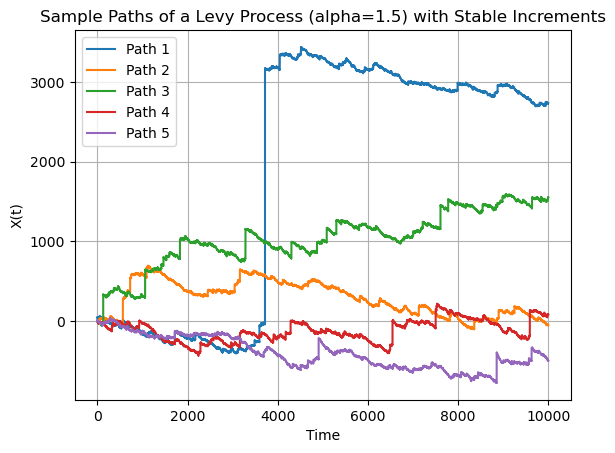

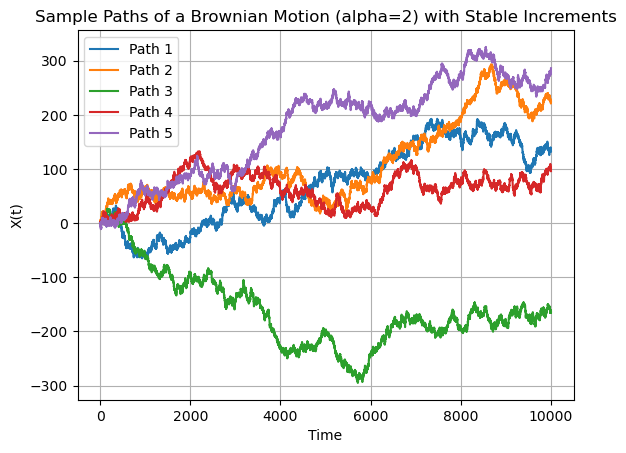

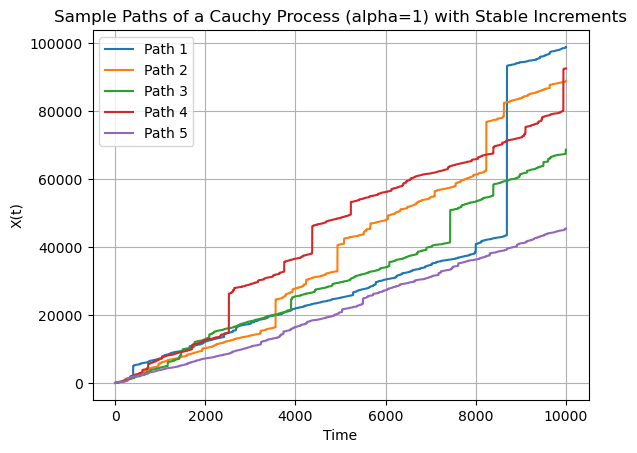

In [4]:
c = 1
alpha = 1.5
beta = 1
gamma = 1
mi = 0

T = 10000
delta = 0.5
x0 = 0

numberOfPaths = 5
# Generate multiple paths on one plot
for i in range(numberOfPaths):
    Xt = generate_process(alpha, beta, gamma, mi, delta, T, c, x0)
    plt.plot(np.arange(0, T+delta, delta), Xt, label=f'Path {i+1}')
plt.title(f'Sample Paths of a Levy Process (alpha={alpha}) with Stable Increments')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.grid()
plt.legend()
plt.show()

alpha = 2
for i in range(numberOfPaths):
    Xt = generate_process(alpha, beta, gamma, mi, delta, T, c, x0)
    plt.plot(np.arange(0, T+delta, delta), Xt, label=f'Path {i+1}')
plt.title(f'Sample Paths of a Brownian Motion (alpha={alpha}) with Stable Increments')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.grid()
plt.legend()
plt.show()  

alpha = 1
for i in range(numberOfPaths):
    Xt = generate_process(alpha, beta, gamma, mi, delta, T, c, x0)
    plt.plot(np.arange(0, T+delta, delta), Xt, label=f'Path {i+1}')
plt.title(f'Sample Paths of a Cauchy Process (alpha={alpha}) with Stable Increments')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.grid()
plt.legend()
plt.show()



Problem 2 (Narzędzia do analizy procesów). Zaimplementuj następujące narzędzia:
- • estymator funkcji kwantylowej;
- • estymator funkcji charakterystycznej.
Następnie odpowiedz na poniższe pytania. Dla procesów α-stabilnych:
- • jak powinna zachowywać się funkcja charakterystyczna w zależności od czasu t?
φXt (s) = E(exp{iXts}) = . . .
Czy istnieje twierdzenie związane z takimi procesami (a może nawet dla szerszej klasy,
np. procesów Lévy’ego?)
- • jak powinny zachowywać się linie kwantylowe?
- • czym jest samopodobieństwo i jak można je sprawdzić?
- • jak powinny zachowywać się linie kwantylowe przyrostów takiego procesu?


Problem 3 (Zadanie dodatkowe). Możemy traktować skończenie wymiarowe rozkłady [Xt1 , Xt2 , . . . , Xtn ]
procesu (Xt)t≥0 jako wektor, a zatem możemy symulować wartości takiego procesu w skoń-
czonej liczbie punktów, wykorzystując metody wielowymiarowe (dla wektorów).
Porównaj szybkość i dokładność obu metod

Potem t -> E^hat X_t (dla B(t)->0)\
t -> Var^hat X_t (-||- t)\
t -> q^hat_eps(X_t), eps = 0.05,0.95

In [12]:
def generate_comparision_plots(numberOfPaths=1000, alpha=2, beta=1, gamma=1, mi=0, delta=0.5, T=1000, c=1, x0=0):
    #finalValues[pathIndex][time] = value
    finalValues = np.zeros((numberOfPaths, int(T/delta) + 1))
    for i in tqdm(range(numberOfPaths)):
        Xt = generate_process(alpha, beta, gamma, mi, delta, T, c, x0)
        finalValues[i] = Xt

    plt.plot(np.arange(0, T+delta, delta), finalValues.T, color='red', alpha=0.5)
    plt.title(f'Sample Paths of a Levy Process (alpha={alpha}) with Stable Increments')
    plt.xlabel('Time')
    plt.ylabel('X(t)')
    plt.grid()
    plt.show()  

    #Take avg across paths for each time point
    avgValues = np.mean(finalValues, axis=0)
    plt.plot(np.arange(0, T+delta, delta), avgValues, label='Average Path')
    plt.title(f'Average Path of a Levy Process (alpha={alpha}) with Stable Increments')
    plt.xlabel('Time')
    plt.ylabel('Average X(t)')
    plt.grid()
    plt.legend()
    plt.show()

    #Take variance across paths for each time point
    varValues = np.var(finalValues, axis=0)
    plt.plot(np.arange(0, T+delta, delta), varValues, label='Variance Path')
    plt.title(f'Variance Path of a Levy Process (alpha={alpha}) with Stable Increments')
    plt.xlabel('Time')
    plt.ylabel('Variance X(t)')
    plt.grid()
    plt.legend()
    plt.show()


    #Take top 5% and bottom 5% across paths for each time point
    top5Percent = np.percentile(finalValues, 95, axis=0)
    bottom5Percent = np.percentile(finalValues, 5, axis=0)
    plt.plot(np.arange(0, T+delta, delta), top5Percent, label='Top 5% Path', linewidth=2)
    plt.plot(np.arange(0, T+delta, delta), bottom5Percent, label='Bottom 5% Path', linewidth=5)
    plt.title(f'Extremal Paths of a Levy Process (alpha={alpha}) with Stable Increments')
    plt.xlabel('Time')
    plt.ylabel('X(t)')
    plt.grid()
    plt.legend()
    plt.show()


100%|██████████| 10000/10000 [00:05<00:00, 1773.02it/s]


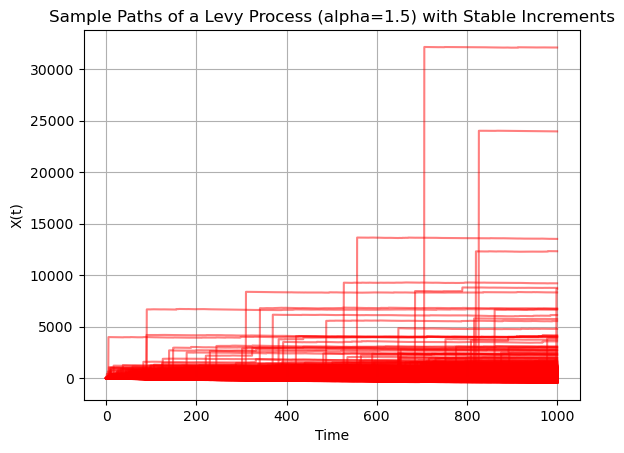

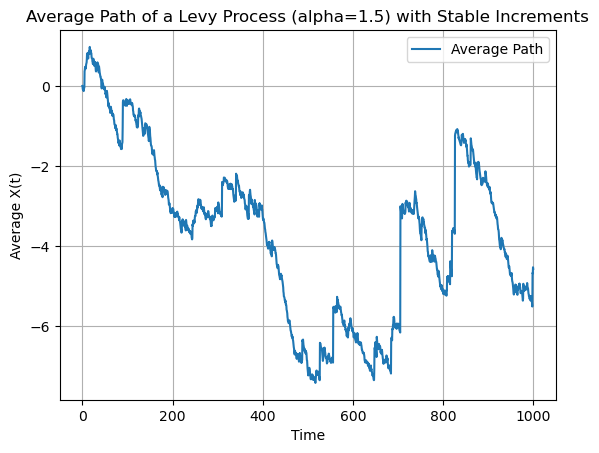

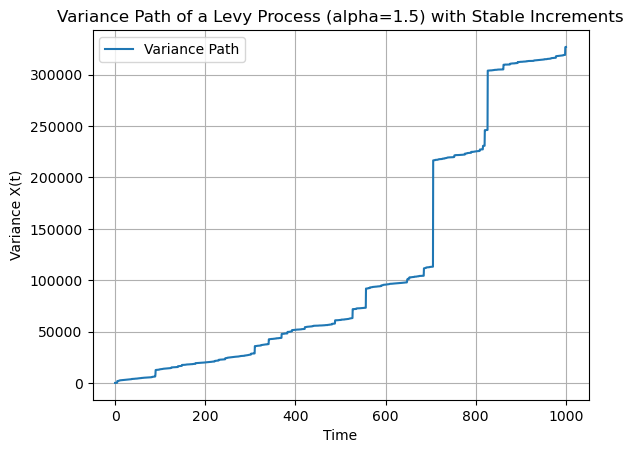

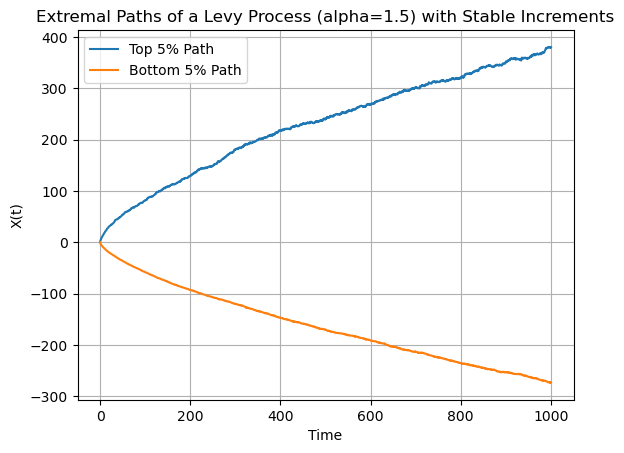

100%|██████████| 10000/10000 [00:04<00:00, 2385.94it/s]


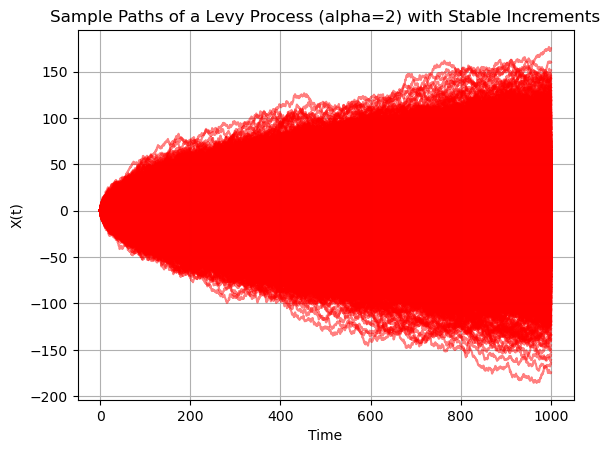

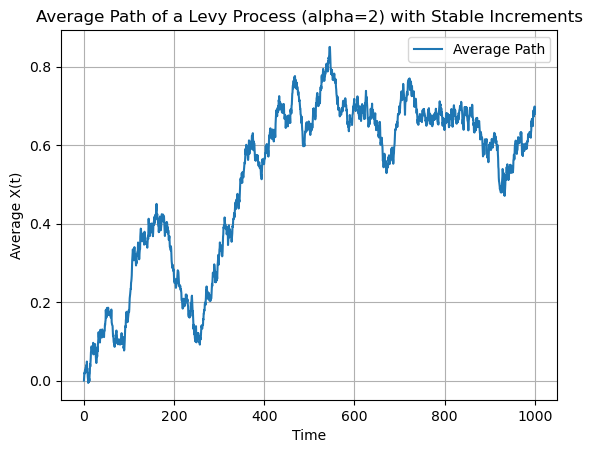

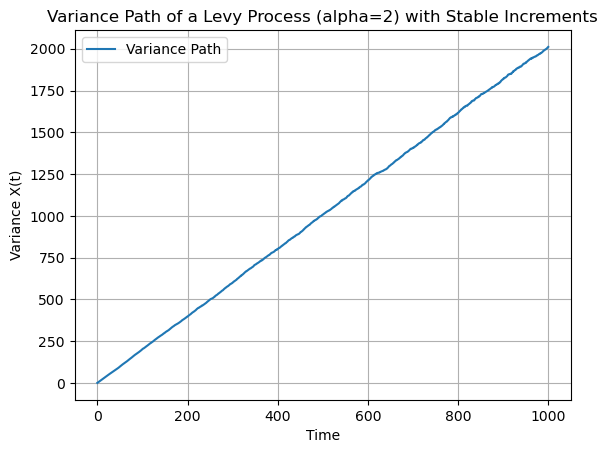

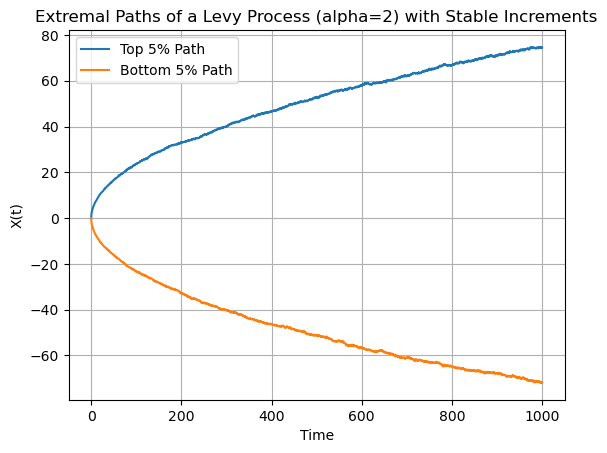

In [6]:
T = 1000

alpha = 1.5
generate_comparision_plots(numberOfPaths=10000, alpha=alpha, T=T)

alpha = 2
generate_comparision_plots(numberOfPaths=10000, alpha=alpha, T=T)

100%|██████████| 10000/10000 [00:02<00:00, 3760.57it/s]


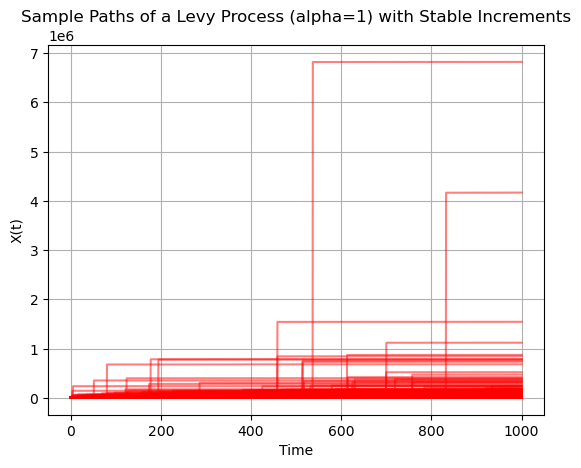

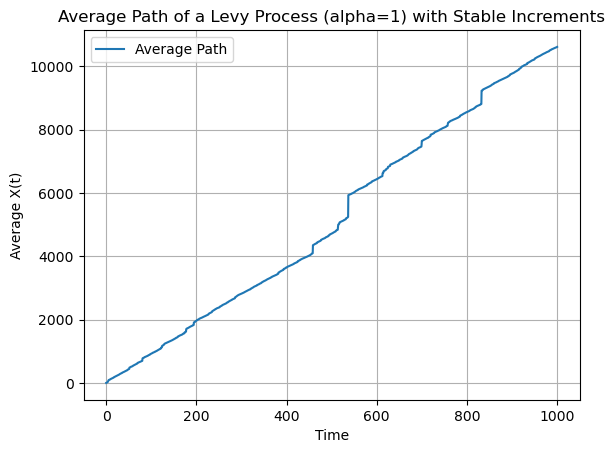

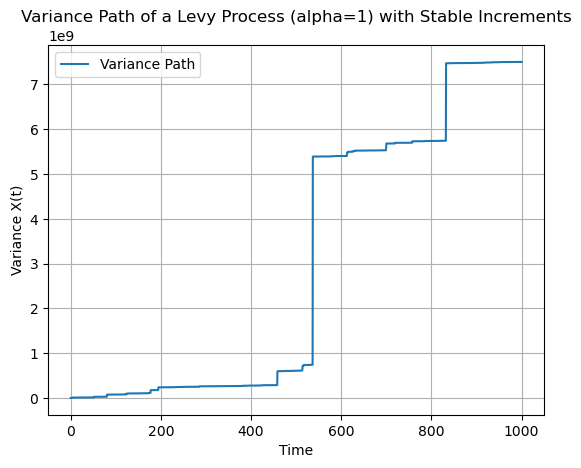

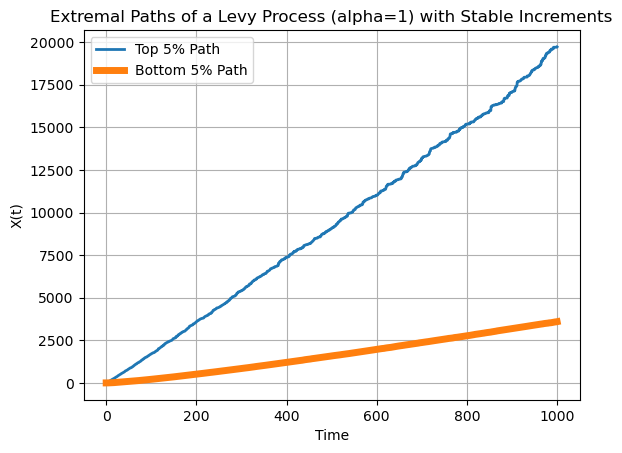

In [13]:
T = 1000
alpha = 1
generate_comparision_plots(numberOfPaths=10000, alpha=alpha, T=T)


100%|██████████| 10000/10000 [00:03<00:00, 2801.69it/s]


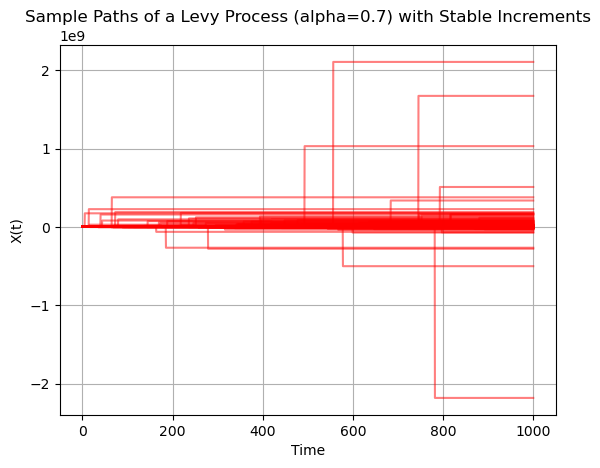

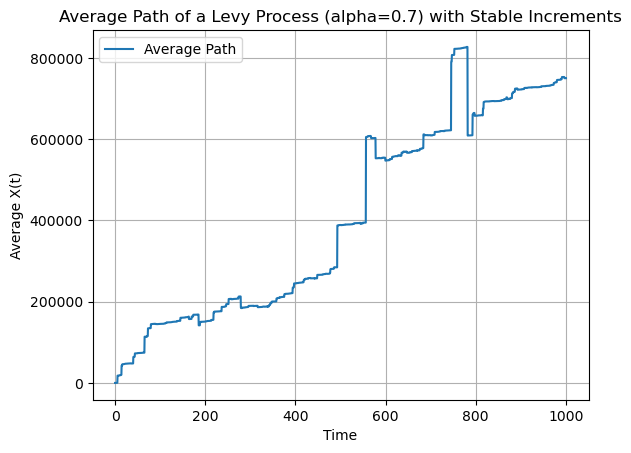

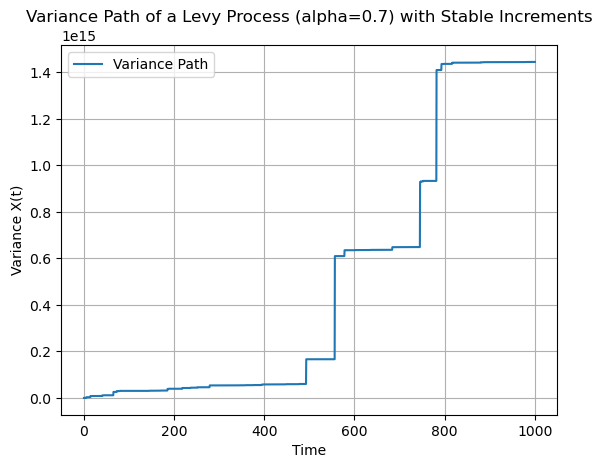

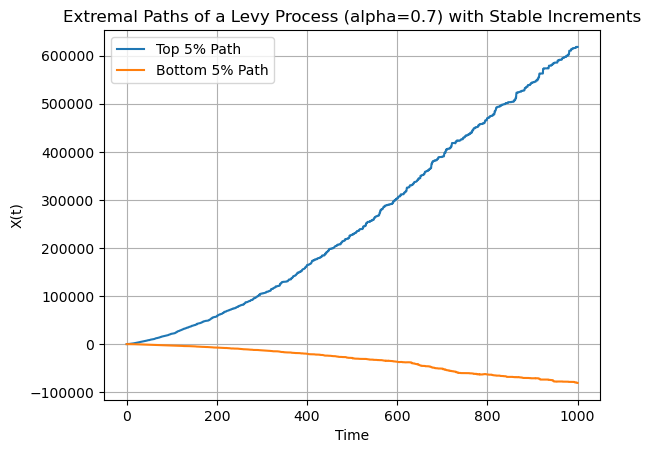

In [9]:
T = 1000
alpha = 0.7
beta = 0.5
numberOfPaths = 10000
generate_comparision_plots(numberOfPaths=numberOfPaths, alpha=alpha, beta=beta, T=T)